In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             classification_report, RocCurveDisplay)

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

best_model = joblib.load('../models/best_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

print("All loaded!")
print(f"Test size: {X_test.shape}")

All loaded!
Test size: (1409, 22)


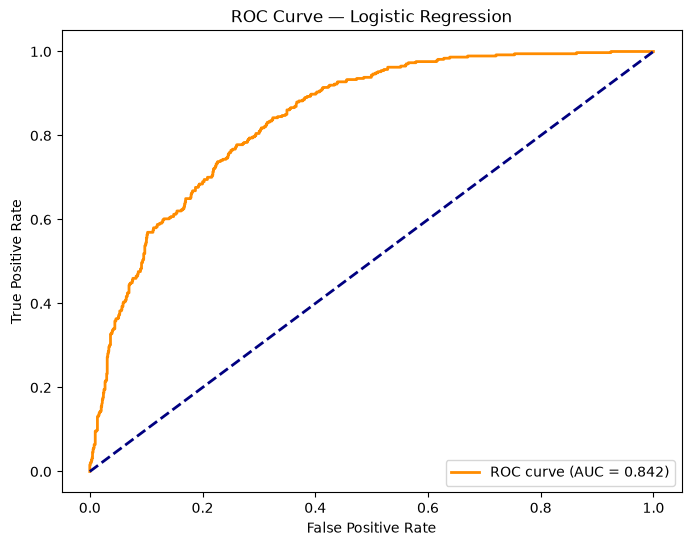

Test AUC: 0.842


In [2]:
# Predictions
y_prob = best_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.savefig('../reports/roc_curve.png')
plt.show()

print(f"Test AUC: {roc_auc:.3f}")

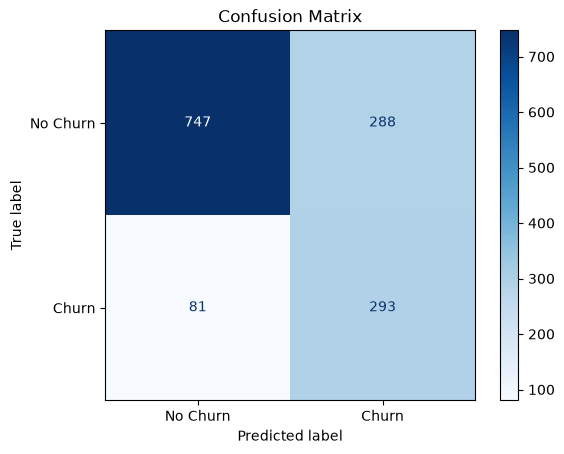

True Negatives  (sahi No): 747
False Positives (galat Yes): 288
False Negatives (miss churners): 81
True Positives  (sahi Yes): 293


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('../reports/confusion_matrix.png')
plt.show()

# Numbers print karo
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (sahi No): {tn}")
print(f"False Positives (galat Yes): {fp}")
print(f"False Negatives (miss churners): {fn}")
print(f"True Positives  (sahi Yes): {tp}")